In [2]:
from scipy.stats import chi2_contingency

# ad and pas total 
ad_total = 564577
pas_total =  23524

# ad and psa : converted  
ad_converted =  14423
pas_converted = 420

# ad and psa : not converted 
ad_not_converted =  ad_total - ad_converted
pas_not_converted = pas_total - pas_converted

"""hypothesis"""
# H-null:  convertion is independent from test_groups(ad and pas)
# H-alter : convertion is independent from test_groups(ad and pas)

contingency = [
    [14423, 550154],
    [420, 23104]
]

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"chi-square : {chi2:.2f}, p-value: {p:.2e}")

chi-square : 54.01, p-value: 2.00e-13



If the ad truly had no effect, the probability of observing a difference this large is about 0.00000000002%.
This is far below the common significance level:

α=0.05

Therefore:

Reject H₀

and conclude:

Conversion is not independent of test group.




# Visualization 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load data 
data =  pd.read_csv("marketing_AB.csv")
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


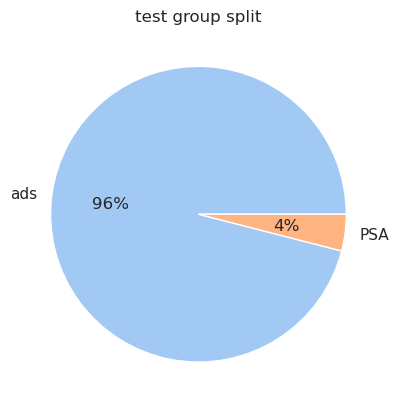

In [7]:
# test grpup split
sns.set_theme()

# Define your data
labels = ['ads','PSA']

# Grab a premium Seaborn color scheme 
colors = sns.color_palette('pastel')[0:2]

# Generate the plot using Matplotlib
plt.pie(data['pct_of_total'], labels=labels, colors=colors, autopct='%.0f%%')
plt.title('test group split')
plt.savefig("test_grpup_split.png")
plt.show()

In [11]:
data = pd.read_csv("conversion_rate.csv")  
data.head()

,test group,total_users,converted_user,coversion_rate_pct
0,ad,564577,14423,2.55
1,psa,23524,420,1.79


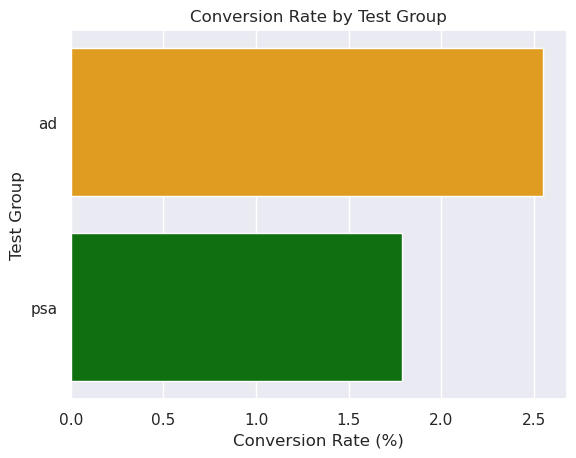

In [21]:
sns.barplot(
    data=data,
    x='coversion_rate_pct',
    y='test group',
    hue='test group',
    palette=['orange', 'green'],
    orient='h',
    legend=False
)

plt.title('Conversion Rate by Test Group')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Test Group')

plt.savefig("conversion_rate_by_test_group.png")
plt.show()

In [23]:
data = pd.read_csv("conv_rate_by_num_ads.csv")
data.head()

,ads_bucket,users,conversion_rate_pct
0,100+ ads,22054,17.14
1,1-10 ads,249499,0.33
2,11-50 ads,248875,1.89
3,51-100 ads,44149,11.63


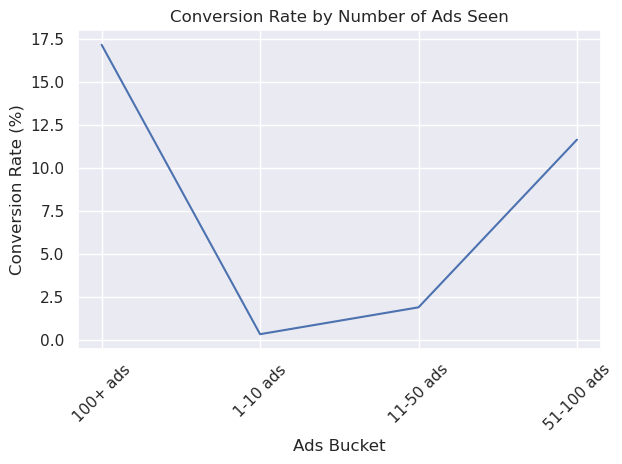

In [25]:
# Conversion Rate vs Ad Frequency
sns.lineplot(
    data=data,
    x='ads_bucket',
    y='conversion_rate_pct'
)

plt.title('Conversion Rate by Number of Ads Seen')
plt.xlabel('Ads Bucket')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("conversion_rate_by_ads.png")
plt.show()

In [26]:
# conversion rate by hour 
data = pd.read_csv("cov_rate_by_hour.csv")
data.head()

,most ads hour,users,conversion_rate_pct
0,16,35963,3.09
1,20,27846,3.03
2,15,42855,2.98
3,21,28895,2.92
4,14,43779,2.86


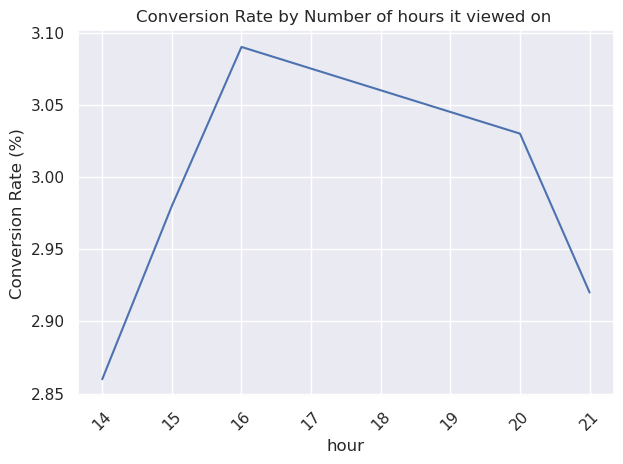

In [27]:
# Conversion Rate vs Ad Frequency
sns.lineplot(
    data=data,
    x='most ads hour',
    y='conversion_rate_pct'
)

plt.title('Conversion Rate by Number of hours it viewed on ')
plt.xlabel('hour')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("conversion_rate_by_ads_hour.png")
plt.show()